### Evaluation and Xai 
#### Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os

# Set visual style
plt.rcParams['figure.figsize'] = (10, 6)

# Load the saved model from Notebook 04
MODEL_PATH = '../saved_models/advanced_densenet.keras'
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

# Define your classes (Ensure these match the order from your training dataset)
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
IMG_SIZE = (224, 224)

Loading model...
Model loaded successfully!


### The Grad-CAM Algorithm
Because we used Transfer Learning, our DenseNet121 is actually nested inside our custom model. This function carefully unpacks that nested model, watches the gradients (the math the model uses to learn), and extracts the final convolutional layer to generate the heatmap.

In [6]:
"""def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Identify the nested base model (DenseNet) and its final activation layer
    base_model = model.get_layer('densenet121')
    last_conv_layer_name = 'relu' # This is the final layer in DenseNet before pooling
    
    # 2. Create a sub-model that outputs both the feature map and the base model's final output
    inner_model = tf.keras.models.Model(
        [base_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 3. Use GradientTape to record the math operations
    with tf.GradientTape() as tape:
        # Pass the raw image through our custom preprocessing layers (like augmentation)
        x = img_array
        for layer in model.layers:
            if layer.name == 'densenet121':
                break
            x = layer(x) # Apply early layers
            
        # Get the feature maps and base output
        last_conv_layer_output, base_model_output = inner_model(x)
        tape.watch(last_conv_layer_output)

        # Pass the output through our custom classification head (GlobalAvgPool, Dropout, Dense)
        preds = base_model_output
        idx = model.layers.index(base_model)
        for layer in model.layers[idx+1:]:
            preds = layer(preds)

        # Get the score for the predicted class
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Compute the gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Average the gradients to find the most "important" features
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Multiply the feature map by the feature importance to get the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds[0].numpy()"""
def make_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Identify the nested base model and its final activation layer
    base_model = model.get_layer('densenet121')
    last_conv_layer_name = 'relu' 
    
    # 2. Create a sub-model that outputs both the feature map and the base model's final output
    inner_model = tf.keras.models.Model(
        [base_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 3. Preprocess the image manually (Bypasses the random flip augmentation!)
    # We copy the array so we don't alter the original image being displayed
    preprocessed_img = tf.keras.applications.densenet.preprocess_input(np.copy(img_array))

    # 4. Use GradientTape to record the math operations
    with tf.GradientTape() as tape:
        # Pass the preprocessed image directly into the base model
        last_conv_layer_output, base_model_output = inner_model(preprocessed_img)
        tape.watch(last_conv_layer_output)

        # Pass the output through our custom classification head 
        # (GlobalAvgPool -> BatchNorm -> Dropout -> Dense)
        preds = base_model_output
        idx = model.layers.index(base_model)
        for layer in model.layers[idx+1:]:
            preds = layer(preds, training=False) # Ensure dropout is OFF during diagnosis

        # Get the score for the predicted class
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Compute the gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Generate the heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy(), preds[0].numpy()

### Visualization Overlay

In [7]:
def display_gradcam(img_path, heatmap, alpha=0.6):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    
    # Rescale heatmap to a range 0-255
    heatmap_rescaled = np.uint8(255 * heatmap)

    # Use OpenCV to apply a color map to the heatmap
    jet = plt.colormaps.get_cmap("jet")
    
    # Extract RGB values from the colormap and drop the alpha channel
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_rescaled]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on the original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return img, superimposed_img

### Execute and Plot!

e:\fourth_sem\brain_tumor_detection\brain_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


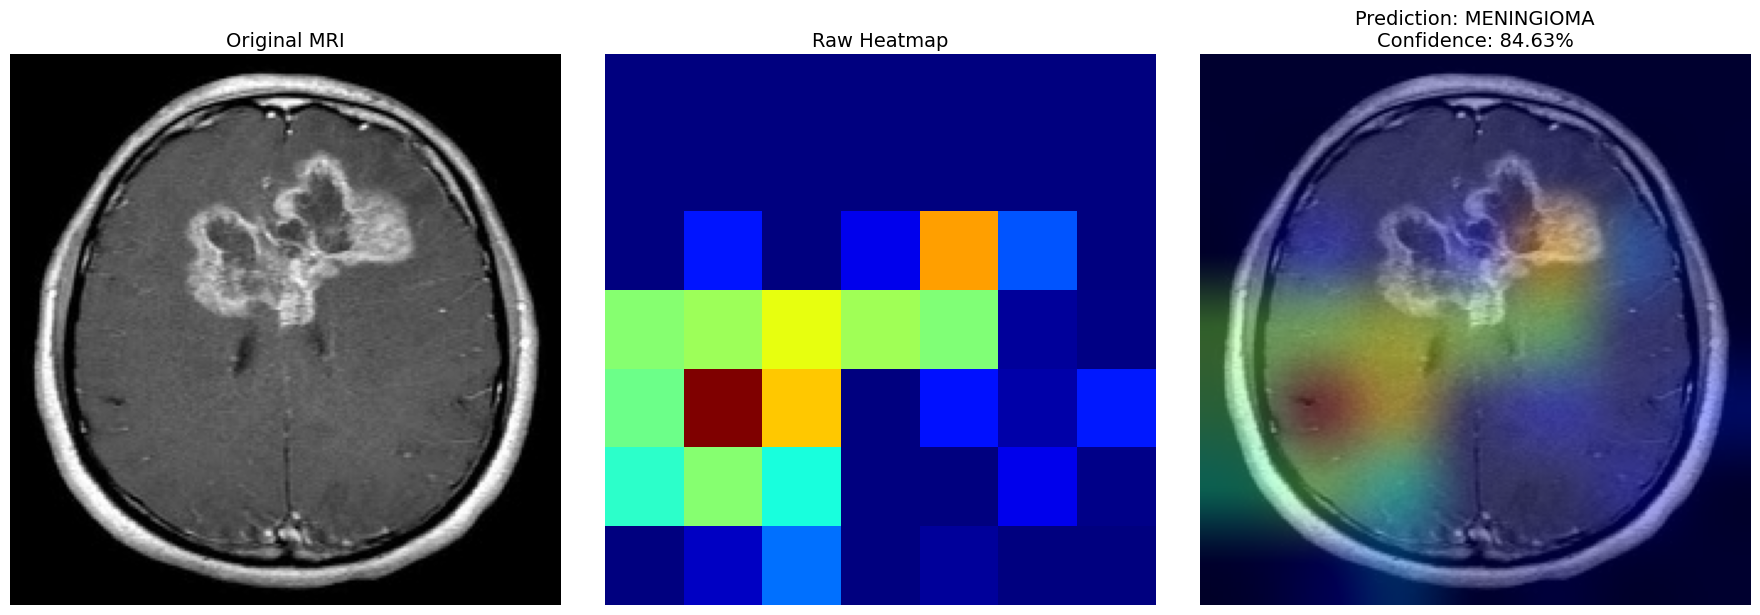

In [8]:
# Select a random test image to explain
TEST_IMG_PATH = r'E:\fourth_sem\brain_tumor_detection\datasets\03_processed\Testing\glioma\Te-gl_1.jpg' # <--- UPDATE THIS FILE NAME

# Prepare the image for the model
img_array = tf.keras.utils.load_img(TEST_IMG_PATH, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img_array)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

# 1. Generate the heatmap and prediction
heatmap, predictions = make_gradcam_heatmap(img_array, model)

# 2. Get the predicted class name and confidence
predicted_class_idx = np.argmax(predictions)
predicted_class_name = CLASS_NAMES[predicted_class_idx]
confidence = predictions[predicted_class_idx] * 100

# 3. Create the visual overlay
original_img, gradcam_img = display_gradcam(TEST_IMG_PATH, heatmap)

# 4. Plot the results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original MRI", fontsize=14)
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title(f"Raw Heatmap", fontsize=14)
axes[1].axis('off')

axes[2].imshow(gradcam_img)
axes[2].set_title(f"Prediction: {predicted_class_name.upper()}\nConfidence: {confidence:.2f}%", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()